In [2]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 12.1 MB/s  0:00:09 eta 0:00:010:01:02


In [3]:
!pip install xgboost==1.7.6 --quiet

In [2]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 5.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 8.2 MB/s  0:00:00m 9.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.9 MB/s  0:00:05 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]━━━━━━ 5/6 [shap] [numba]


In [2]:
!pip install ipywidgets --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 3.5 MB/s  0:00:005.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 5.8 MB/s  0:00:006.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]━━━━━━━ 2/3 [ipywidgets]


In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt

In [2]:
# Paths to your preprocessed CSV files
X_train_reg = pd.read_csv('../data/preprocessed/regression/X_train_reg.csv')
X_test_reg = pd.read_csv('../data/preprocessed/regression/X_test_reg.csv')
y_train_reg = pd.read_csv('../data/preprocessed/regression/y_train_reg.csv')
y_test_reg = pd.read_csv('../data/preprocessed/regression/y_test_reg.csv')

# If y_train/y_test have one column, convert to Series
y_train_reg = y_train_reg.iloc[:, 0]
y_test_reg = y_test_reg.iloc[:, 0]

In [3]:
# Initialize model
xgb_reg = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

# Train
xgb_reg.fit(X_train_reg, y_train_reg)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


In [4]:
# Predict
y_pred_reg = xgb_reg.predict(X_test_reg)

# Metrics
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Regression RMSE: {rmse:.2f}")
print(f"Regression R^2: {r2:.2f}")

Regression RMSE: 100.91
Regression R^2: 0.84


Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


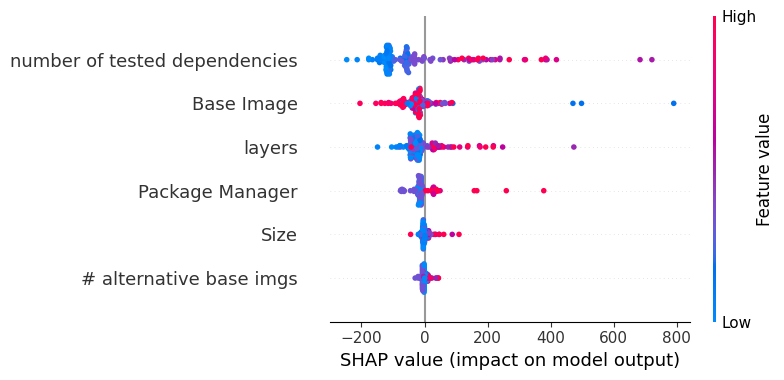

In [5]:
import shap
X_test_reg = pd.DataFrame(X_test_reg, columns=X_train_reg.columns)
# Regression SHAP
explainer_reg = shap.Explainer(xgb_reg, X_train_reg)
shap_values_reg = explainer_reg(X_test_reg)

# Summary plot
shap.summary_plot(shap_values_reg, X_test_reg)

# Force plot (optional)
shap.initjs()
shap.force_plot(
    explainer_reg.expected_value,
    shap_values_reg.values[0],
    X_test_reg.iloc[0]
)

In [6]:
import joblib
joblib.dump(xgb_reg, '../src/model_store/xgb_reg_model.pkl')
print("XGBoost Regression model saved!")

XGBoost Regression model saved!


In [7]:
# Predict number of vulnerabilities
y_pred_reg = xgb_reg.predict(X_test_reg)

# Show first 10 predictions vs actual
pred_df = pd.DataFrame({
    'Actual': y_test_reg.values,
    'Predicted': y_pred_reg
})

print(pred_df.head(10))

   Actual   Predicted
0      70   70.371223
1      10   10.171676
2       0    0.471193
3       0    0.903344
4     750  509.855865
5      23   56.562077
6      77  105.956848
7      10   10.171676
8     556  285.821014
9      44   44.881790


#### Classification Model

In [8]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt

In [9]:
X_train_clf = pd.read_csv('../data/preprocessed/classification/X_train_clf.csv')
X_test_clf = pd.read_csv('../data/preprocessed/classification/X_test_clf.csv')
y_train_clf = pd.read_csv('../data/preprocessed/classification/y_train_clf.csv')
y_test_clf = pd.read_csv('../data/preprocessed/classification/y_test_clf.csv')

# Convert target to Series
y_train_clf = y_train_clf.iloc[:, 0]
y_test_clf = y_test_clf.iloc[:, 0]


In [10]:
print("Training features:", X_train_clf.shape)
print("Testing features:", X_test_clf.shape)
print("Training target sample:\n", y_train_clf.head())
print("Testing target sample:\n", y_test_clf.head())

Training features: (622, 10)
Testing features: (156, 10)
Training target sample:
 0    1
1    1
2    1
3    0
4    1
Name: secure, dtype: int64
Testing target sample:
 0    1
1    0
2    0
3    1
4    0
Name: secure, dtype: int64


In [11]:
# Initialize classifier
xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'  # keep this
)


# Train model
xgb_clf.fit(X_train_clf, y_train_clf)

,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [12]:
# Predict
y_pred_clf = xgb_clf.predict(X_test_clf)

# Accuracy
accuracy = accuracy_score(y_test_clf, y_pred_clf)
print(f"Classification Accuracy: {accuracy:.2f}")

# Detailed report
print("\nClassification Report:\n", classification_report(y_test_clf, y_pred_clf))

# Confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
print("\nConfusion Matrix:\n", cm)

Classification Accuracy: 0.99

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       100
           1       1.00      0.96      0.98        56

    accuracy                           0.99       156
   macro avg       0.99      0.98      0.99       156
weighted avg       0.99      0.99      0.99       156


Confusion Matrix:
 [[100   0]
 [  2  54]]


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


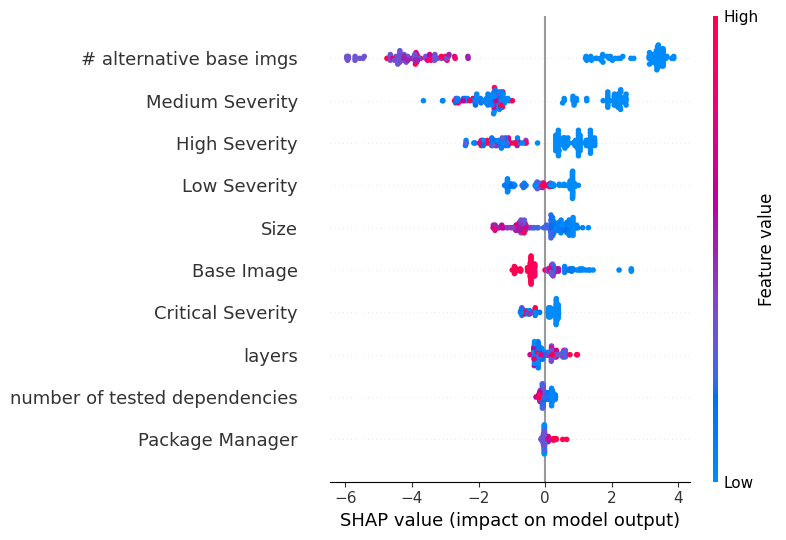

In [13]:
# Classification SHAP
explainer_clf = shap.Explainer(xgb_clf, X_train_clf)
shap_values_clf = explainer_clf(X_test_clf)

# Summary plot
shap.summary_plot(shap_values_clf, X_test_clf)

# Force plot (binary classification)
shap.force_plot(
    explainer_clf.expected_value,
    shap_values_clf.values[0],
    X_test_clf.iloc[0]
)

In [14]:
import joblib
joblib.dump(xgb_clf, '../src/model_store/xgb_clf_model.pkl')
print("XGBoost Classification model saved!")

XGBoost Classification model saved!


In [15]:
# Load the dataset (classification target included)
df = pd.read_csv('../data/preprocessed/classification/X_train_clf.csv')
y_train = pd.read_csv('../data/preprocessed/classification/y_train_clf.csv')

# Combine for easy checking (optional)
df['secure'] = y_train

# Count secure vs insecure
counts = df['secure'].value_counts()
print(counts)

secure
0    368
1    254
Name: count, dtype: int64


In [16]:
percent = df['secure'].value_counts(normalize=True) * 100
print(percent)

secure
0    59.163987
1    40.836013
Name: proportion, dtype: float64


In [17]:
def generate_human_readable_text(
    row,
    predicted_vuln,
    predicted_status,
    shap_reg_row,
    shap_clf_row
):
    """
    row: row from X_test_clf
    predicted_vuln: regression prediction
    predicted_status: classification prediction (0=insecure, 1=secure)
    shap_reg_row: SHAP values for this row (regression)
    shap_clf_row: SHAP values for this row (classification)
    """

    critical = int(row['Critical Severity'])
    high = int(row['High Severity'])
    medium = int(row['Medium Severity'])
    low = int(row['Low Severity'])

    status_text = "secure" if predicted_status == 1 else "insecure"

    # -------- Regression SHAP interpretation --------
    reg_reasons = []
    for feature, shap_val, value in zip(row.index, shap_reg_row, row.values):
        if shap_val > 0:
            reg_reasons.append(
                f"{feature} = {value} contributed to increasing the predicted vulnerability count"
            )
        elif shap_val < 0:
            reg_reasons.append(
                f"{feature} = {value} contributed to reducing the predicted vulnerability count"
            )

    # -------- Classification SHAP interpretation --------
    clf_reasons = []
    for feature, shap_val, value in zip(row.index, shap_clf_row, row.values):
        if shap_val > 0:
            clf_reasons.append(
                f"{feature} = {value} increased the likelihood of being classified as insecure"
            )
        elif shap_val < 0:
            clf_reasons.append(
                f"{feature} = {value} reduced the likelihood of being classified as insecure"
            )

    output_text = f"""
Image has an estimated {predicted_vuln:.0f} total vulnerabilities:
{critical} critical, {high} high-severity,
{medium} medium-severity, and {low} low-severity vulnerabilities.

Regression Model Explanation (Why this number):
- """ + "\n- ".join(reg_reasons[:5]) + f"""

Classification Model Explanation (Why this status):
- """ + "\n- ".join(clf_reasons[:5]) + f"""

Final Security Status:
This Docker image is classified as {status_text.upper()}.
"""

    return output_text.strip()

In [18]:
all_outputs = []

for i in range(len(X_test_clf)):
    row = X_test_clf.iloc[i]

    predicted_vuln = y_pred_reg[i]
    predicted_status = y_pred_clf[i]

    shap_reg_row = shap_values_reg.values[i]
    shap_clf_row = shap_values_clf.values[i]

    text = generate_human_readable_text(
        row,
        predicted_vuln,
        predicted_status,
        shap_reg_row,
        shap_clf_row
    )

    all_outputs.append(text)

df_outputs = pd.DataFrame({'output_text': all_outputs})
df_outputs.to_csv('../data/preprocessed/final_output_text.csv', index=False)

print(" Final SHAP-based human-readable outputs saved!")


 Final SHAP-based human-readable outputs saved!


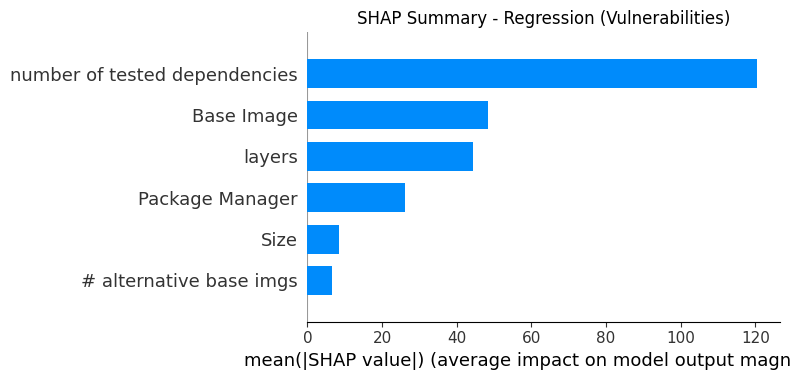

In [19]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# SHAP Summary Plot - Regression

explainer_reg = shap.Explainer(xgb_reg, X_train_reg)
shap_values_reg = explainer_reg(X_test_reg)

plt.title("SHAP Summary - Regression (Vulnerabilities)")
shap.summary_plot(shap_values_reg, X_test_reg, plot_type="bar")  # global feature importance

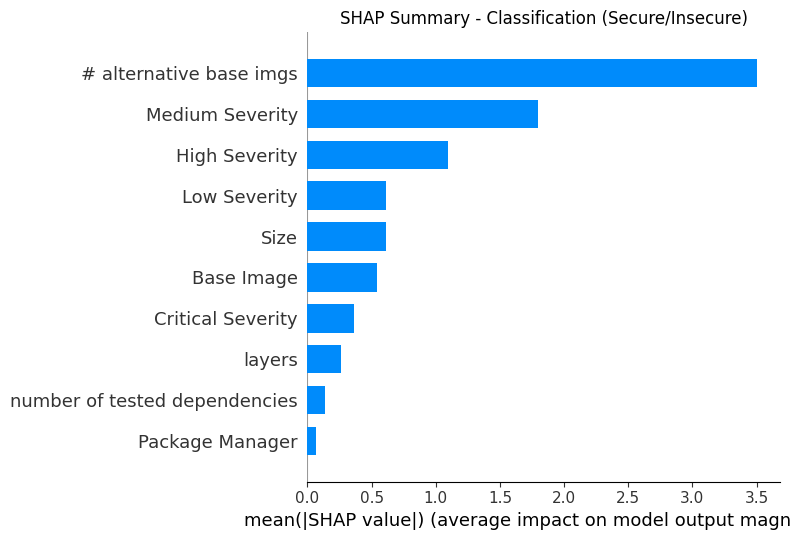

In [20]:
# SHAP Summary Plot - Classification

explainer_clf = shap.Explainer(xgb_clf, X_train_clf)
shap_values_clf = explainer_clf(X_test_clf)

plt.title("SHAP Summary - Classification (Secure/Insecure)")
shap.summary_plot(shap_values_clf, X_test_clf, plot_type="bar")


In [21]:
# SHAP Force Plot - Local Explanation for 1 image

# Regression
shap.force_plot(explainer_reg.expected_value, shap_values_reg.values[0], X_test_reg.iloc[0,:])

# Classification
shap.force_plot(explainer_clf.expected_value, shap_values_clf.values[0], X_test_clf.iloc[0,:])

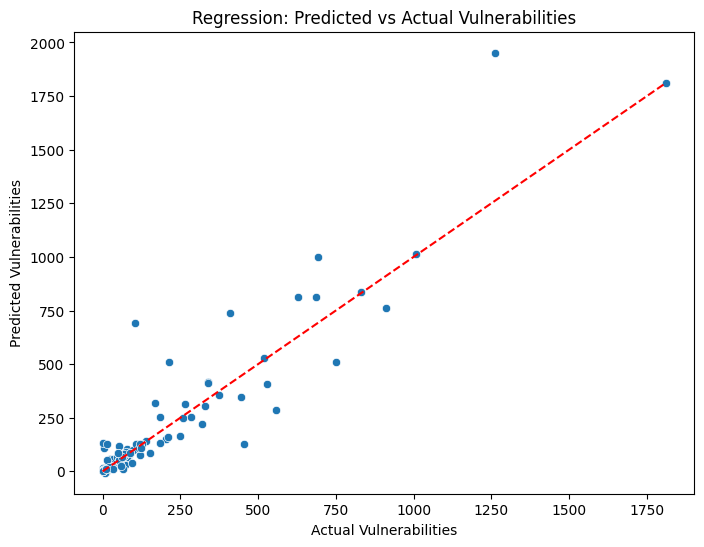

In [22]:
# Predicted vs Actual Vulnerabilities - Regression

y_pred_reg = xgb_reg.predict(X_test_reg)

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_reg, y=y_pred_reg)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--')  # perfect prediction line
plt.xlabel("Actual Vulnerabilities")
plt.ylabel("Predicted Vulnerabilities")
plt.title("Regression: Predicted vs Actual Vulnerabilities")
plt.show()

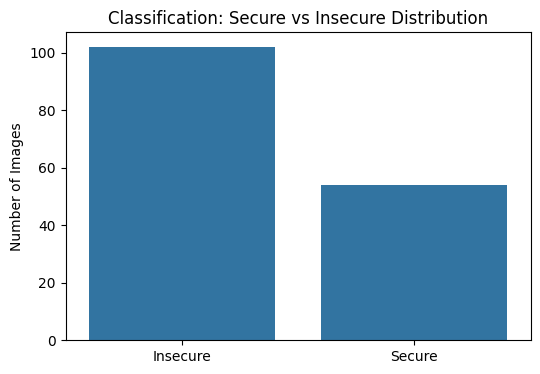

In [23]:
# Secure vs Insecure Distribution - Classification

pred_labels = xgb_clf.predict(X_test_clf)

plt.figure(figsize=(6,4))
sns.countplot(x=pred_labels)
plt.xticks([0,1], ["Insecure", "Secure"])
plt.title("Classification: Secure vs Insecure Distribution")
plt.ylabel("Number of Images")
plt.show()

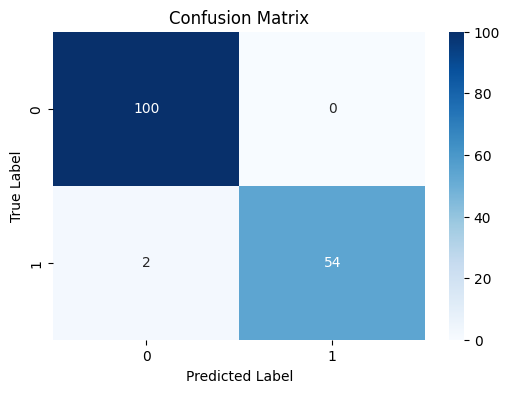

In [24]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [25]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1),
    X_train_reg,
    y_train_reg,
    cv=5,
    scoring='r2'
)

print("Cross Validation R2 Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation R2 Scores: [0.80088913 0.81555462 0.57466543 0.85871553 0.86045438]
Average CV Score: 0.7820558190345764


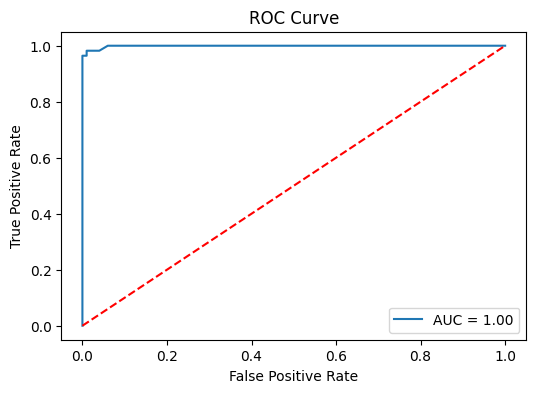

In [26]:
from sklearn.metrics import roc_curve, auc

y_prob = xgb_clf.predict_proba(X_test_clf)[:,1]

fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [27]:
sample = X_test_clf.iloc[5].copy()

sample['layers'] = 50
sample['number of tested dependencies'] = 200

prediction = xgb_clf.predict(pd.DataFrame([sample]))

print("Prediction for modified input:", prediction)

Prediction for modified input: [0]


In [28]:
import time

start = time.time()

for i in range(1000):
    xgb_clf.predict(X_test_clf)

end = time.time()

print("Prediction time:", end-start)

Prediction time: 1.564528226852417
